Loading Data and buid graph

In [1]:
import pandas as pd
import networkx as nx

df = pd.read_csv('2ndfiles/soc-redditHyperlinks-body.tsv', sep='\t')
G = nx.from_pandas_edgelist(df, 
      source='SOURCE_SUBREDDIT', 
      target='TARGET_SUBREDDIT',
      create_using=nx.DiGraph())
G_und = G.to_undirected()
print(f"Nodes: {G_und.number_of_nodes()}, Edges: {G_und.number_of_edges()}")

Nodes: 35776, Edges: 124330


Download and load embeddings

In [3]:
import pandas as pd

# Skip the download — file already exists!
cols = ["SUBREDDIT"] + list(int(i) for i in range(300))
emb = pd.read_csv("2ndfiles/web-redditEmbeddings-subreddits.csv", names=cols)
emb = emb.set_index("SUBREDDIT")

print(emb.shape)
print(emb.loc["leagueoflegends"][:5])

(51278, 300)
0   -2.785298
1   -0.166391
2    1.592624
3   -1.269829
4    2.861522
Name: leagueoflegends, dtype: float64


Create edge features

In [4]:
import numpy as np

def edge_feature(u, v):
    if u in emb.index and v in emb.index:
        return emb.loc[u].values * emb.loc[v].values  # 300-dim
    return None

Sample positive and negative edges

In [5]:
import random

edges = [(u, v) for u, v in G_und.edges() 
         if u in emb.index and v in emb.index]

# Negative samples = random non-existing pairs
nodes = list(emb.index)
neg_edges = []
edge_set = set(G_und.edges())

while len(neg_edges) < len(edges):
    u, v = random.sample(nodes, 2)
    if (u, v) not in edge_set and (v, u) not in edge_set:
        neg_edges.append((u, v))

# Build X, y
X, y = [], []
for u, v in edges:
    X.append(edge_feature(u, v)); y.append(1)
for u, v in neg_edges:
    X.append(edge_feature(u, v)); y.append(0)

X = np.array(X)
y = np.array(y)

Train classifier and get AUC

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

preds = clf.predict_proba(X_test)[:, 1]
print("AUC:", roc_auc_score(y_test, preds))
print(classification_report(y_test, clf.predict(X_test)))

AUC: 0.9655342912772213
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     20842
           1       0.95      0.86      0.90     20664

    accuracy                           0.91     41506
   macro avg       0.91      0.91      0.91     41506
weighted avg       0.91      0.91      0.91     41506



 t-SNE visualization (colored by community)

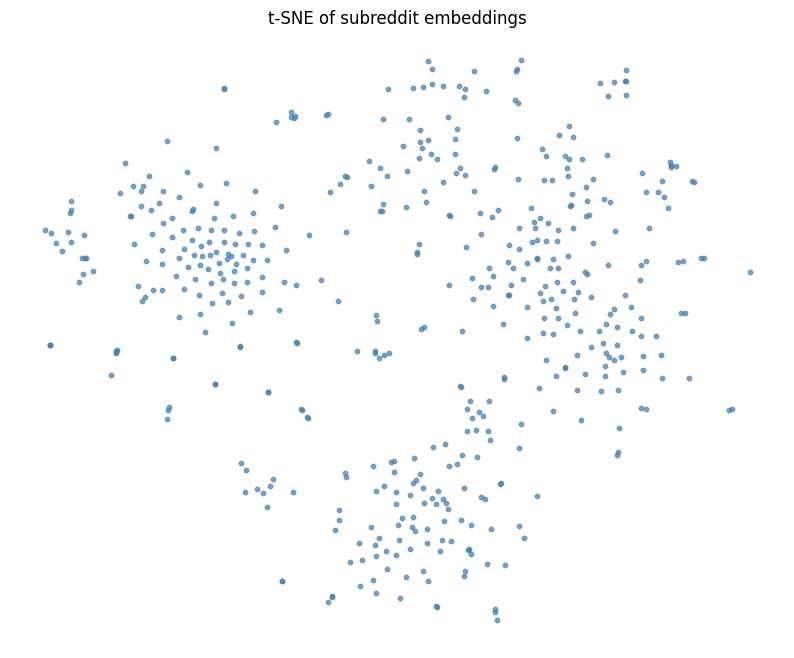

In [7]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

sample_nodes = list(emb.index[:500])
vectors = emb.loc[sample_nodes].values

tsne = TSNE(n_components=2, random_state=42)
coords = tsne.fit_transform(vectors)

# No community colors yet — use plain gray
plt.figure(figsize=(10, 8))
plt.scatter(coords[:, 0], coords[:, 1], 
            c='steelblue', s=10, alpha=0.7)
plt.title("t-SNE of subreddit embeddings")
plt.axis('off')
plt.savefig('tsne.png', dpi=150)
plt.show()